In [1]:
import os

import numpy as np
import pandas as pd
import plotnine as p9
from IPython import get_ipython
from sklearn.model_selection import train_test_split
from vinesforest import VinesForest

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal


In [70]:
def sample_vine_copula(dim=3, seed=12) -> pv.Vinecop:
  # set seed and create random number generator
  rng = np.random.default_rng(seed)

  # Random structure
  # structure = pv.RVineStructure.simulate(dim, seeds=[seed])
  order = [int(x) + 1 for x in rng.permutation(dim)]
  structure = pv.DVineStructure(order=order)

  # Random pair copulas
  pair_copulas = []
  for i in range(dim - 1):
    pair_copulas.append([])
    for J in range(dim - i - 1):
      family = rng.choice(
        [
          pv.BicopFamily.gaussian,
          pv.BicopFamily.gumbel,
          pv.BicopFamily.frank,
        ]
      )
      tau = rng.beta(2, (i + 1) ** (1 / 1)) * 0.7
      rot = (
        0
        if family
        in [
          pv.BicopFamily.gaussian,
          pv.BicopFamily.frank,
        ]
        else rng.choice([0, 90, 180, 270])
      )
      pair_copula = pv.Bicop(family=family, rotation=rot)
      pair_copula.parameters = pair_copula.tau_to_parameters(tau)
      pair_copulas[i].append(pair_copula)

  cop = pv.Vinecop.from_structure(
    structure=structure, pair_copulas=pair_copulas
  )

  return cop

2.8028846238256087 2.820890139875573
2.925583103240273 2.8525361694250564


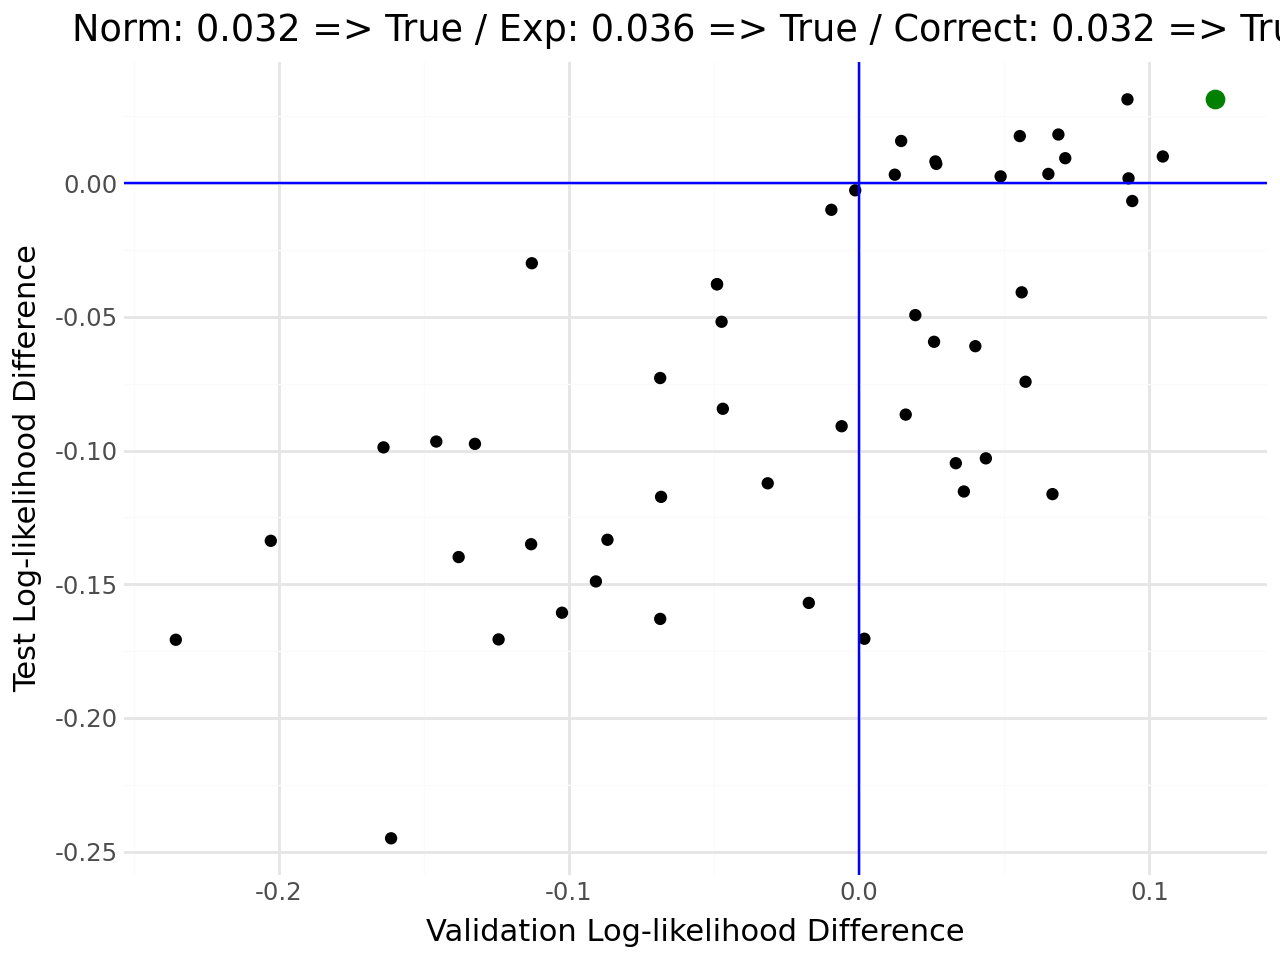

In [ ]:
n_vines = 50
dim = 5
seed = 1111
B = 2000
sample_size = 2000
train_size = 0.5
train_val_split = 0.75
num_threads = min(32, os.cpu_count() + 4)
grid_size = 30

cop = sample_vine_copula(dim=dim, seed=seed)
data = cop.simulate(n=sample_size, seeds=[seed])  # shape: (sample_size, dim)

controls = pv.FitControlsVinecop(
  family_set=[pv.tll],
  num_threads=num_threads,
  nonparametric_grid_size=grid_size,
)

data_train, data_test = train_test_split(
  data, train_size=train_size, random_state=seed
)

forest = VinesForest(
  n_vines=n_vines,
  seed=seed,
  controls=controls,
)
forest.fit(data_train)


def corrected_val_loss(
  val_loss: np.ndarray,
  seed: int = 0,
  B: int = 200,
  alpha: float = 0.9,
  extremum: str = "max",
  use_quantile: bool = True,  # set True to use alpha-quantile instead of mean
):
  """
  Bias-correct the extreme (min or max) of per-model mean validation loss
  using (i) exponential multiplier bootstrap and (ii) Gaussian CLT approximation.

  Parameters
  ----------
  val_loss : (n_models, n_val) np.ndarray
      Per-observation validation loss for each model (rows=models, cols=val obs).
      For 'max' mode this can be a *gain* (e.g., candidate - baseline).
  seed : int
      Random seed.
  B : int
      Number of bootstrap replicates.
  alpha : float
      Quantile level if use_quantile=True.
  extremum : {"min","max"}
      Which extreme to correct (for loss minimization, use "min").
  use_quantile : bool
      If True, use the alpha-quantile of the extreme across bootstrap draws
      instead of the mean (R code uses a quantile in your example).

  Returns
  -------
  dict with:
    uncorrected, corrected_bootstrap_exp, corrected_bootstrap_norm,
    optimism_exp, optimism_norm, val_loss_mean
  """
  rng = np.random.default_rng(seed)
  n_models, n_val = val_loss.shape

  # Per-model validation means
  val_loss_mean = val_loss.mean(axis=1)

  if extremum == "min":
    reduce_fn = np.min
    uncorrected = float(val_loss_mean.min())
  elif extremum == "max":
    reduce_fn = np.max
    uncorrected = float(val_loss_mean.max())
  else:
    raise ValueError("extremum must be 'min' or 'max'")

  # (i) Multiplier bootstrap over validation observations
  W = rng.exponential(scale=1.0, size=(B, n_val))
  W /= W.sum(axis=1, keepdims=True)  # rows sum to 1
  means_boot_exp = W @ val_loss.T  # (B, n_models)

  # (ii) Gaussian approximation for the vector of means
  # Row variables = models, columns = observations
  # Σ_obs is covariance across models for single observations (divides by n_val if bias=True),
  # the covariance of means is Σ_mean = Σ_obs / n_val.
  Sigma_obs = np.cov(val_loss, rowvar=True, bias=True)  # (n_models, n_models)
  Sigma_mean = Sigma_obs / n_val
  means_boot_norm = rng.multivariate_normal(
    val_loss_mean, Sigma_mean, size=B
  )  # (B, n_models)

  # Extreme across models for each bootstrap draw
  ext_exp = reduce_fn(means_boot_exp, axis=1)  # (B,)
  ext_norm = reduce_fn(means_boot_norm, axis=1)  # (B,)

  if use_quantile:
    optimism_exp = float(np.quantile(ext_exp, alpha))
    optimism_norm = float(np.quantile(ext_norm, alpha))
  else:
    optimism_exp = float(ext_exp.mean())
    optimism_norm = float(ext_norm.mean())

  corrected_bootstrap_exp = 2 * uncorrected - optimism_exp
  corrected_bootstrap_norm = 2 * uncorrected - optimism_norm

  return dict(
    uncorrected=float(uncorrected),
    corrected_bootstrap_exp=float(corrected_bootstrap_exp),
    corrected_bootstrap_norm=float(corrected_bootstrap_norm),
    optimism_exp=float(optimism_exp),
    optimism_norm=float(optimism_norm),
    val_loss_mean=val_loss_mean,
  )


diffs_val = forest.logliks_forest - forest.loglik_dissman
loglik_dissman_val = forest.loglik_dissman.mean()
loglik_forest_val = forest.logliks_forest.mean(axis=1)
corrected = corrected_val_loss(diffs_val, B=B)

loglik_dissman_test = np.log(forest.vine_dissman.pdf(data_test)).mean()
loglik_forest_test = (
  np.array([vine.loglik(data_test) for vine in forest.vines])
  / data_test.shape[0]
)


results = pd.DataFrame(
  {
    "loglik_val_diff": corrected["val_loss_mean"],
    "loglik_test_diff": loglik_forest_test - loglik_dissman_test,
  }
)

best_vine = results["loglik_val_diff"].idxmax()
print(loglik_dissman_val, loglik_dissman_test)
print(loglik_forest_val[best_vine], loglik_forest_test[best_vine])

correct_exp = (
  (corrected["corrected_bootstrap_exp"] > 0)
  and (loglik_forest_test[best_vine] > loglik_dissman_test)
) or (
  (corrected["corrected_bootstrap_exp"] <= 0)
  and (loglik_forest_test[best_vine] <= loglik_dissman_test)
)
correct_decision_boost = (
  (corrected["corrected_bootstrap_norm"] > 0)
  and (loglik_forest_test[best_vine] > loglik_dissman_test)
) or (
  (corrected["corrected_bootstrap_norm"] <= 0)
  and (loglik_forest_test[best_vine] <= loglik_dissman_test)
)

# Plot log-likelihood differences against test log-likelihoods
(
  p9.ggplot(
    results[results.index != best_vine],
    p9.aes(x="loglik_val_diff", y="loglik_test_diff"),
  )
  + p9.geom_point()
  + p9.geom_hline(yintercept=0, color="blue")
  + p9.geom_vline(xintercept=0, color="blue")
  + p9.geom_point(
    data=results[results.index == best_vine],
    color="green" if correct_decision_boost else "red",
    size=3,
  )
  + p9.labs(
    title=f"Norm: {corrected['corrected_bootstrap_norm']:.3f} => {corrected['corrected_bootstrap_norm'] > 0} / Exp: {corrected['corrected_bootstrap_exp']:.3f} => {corrected['corrected_bootstrap_exp'] > 0} / Correct: {loglik_forest_test[best_vine] - loglik_dissman_test:.3f} => {loglik_forest_test[best_vine] > loglik_dissman_test}",
    x="Validation Log-likelihood Difference",
    y="Test Log-likelihood Difference",
  )
  + p9.theme_minimal()
)


# y_pred = (
#   2 * loglik_val_forest
#   - np.array(means_boot).max(axis=1).mean()
#   - loglik_val_dissman
# ) > 0
# y_true = results["loglik_test_diff"] > 0

# print(confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred))